### TASK 1 · Predicting House Prices with Linear Regression
Objective: Build and evaluate a linear regression model that predicts house prices based on
features such as area, location, number of rooms, and age. Develop end-to-end skills from
data cleaning through to model interpretation.
Tech Stack: Python, pandas, scikit-learn, matplotlib, seaborn, Jupyter Notebook
Feature Checklist:
●  load dataset and perform EDA: null check, descriptive statistics, distribution of the
target variable (price)
●  Feature selection discussion: identify which features are likely predictors; explain
reasoning in a markdown cell
●  Handle missing values and encode categorical features (One-Hot Encoding)
●  Correlation heatmap: identify features most correlated with house price
●  Train/test split (80/20)
●  Train a Linear Regression model using scikit-learn
●  Evaluate model using: Mean Squared Error (MSE), Root Mean Squared Error
(RMSE), and R² score
●  Scatter plot: actual prices vs. predicted prices (the closer to a diagonal line, the
better)
●  Residual plot: check that residuals are randomly distributed (no systematic pattern)
●  Coefficient analysis: which features have the highest positive/negative impact on
price?
●  (Bonus) Compare Linear Regression against a Ridge or Lasso regularised model
Self-Sourcing Guideline: Search "house price prediction dataset" on Kaggle.com (the
"Ames Housing Dataset" and "House Prices: Advanced Regression Techniques" competition
datasets are both excellent). Search "linear regression house price prediction Python
tutorial" on YouTube. Reference the scikit-learn documentation for LinearRegression,
mean_squared_error, and r2_score.

In [4]:
import pandas as pd
import numpy as np 

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge

Load Dataset

In [5]:
df=pd.read_csv("House_Prediction.csv")
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [6]:
df.tail()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


In [7]:
df.shape

(545, 13)

In [8]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


The dataset was successfully loaded into a pandas DataFrame. It contains 545 house records and 13 features, including the target variable price. The dataset has both numerical and categorical variables, and there are no missing values, making it suitable for further exploratory data analysis and model building.

Check Missing Values

In [10]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [11]:
# Check Duplicate Rows
df.duplicated().sum()

np.int64(0)

In [12]:
# Descriptive Statistics

df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


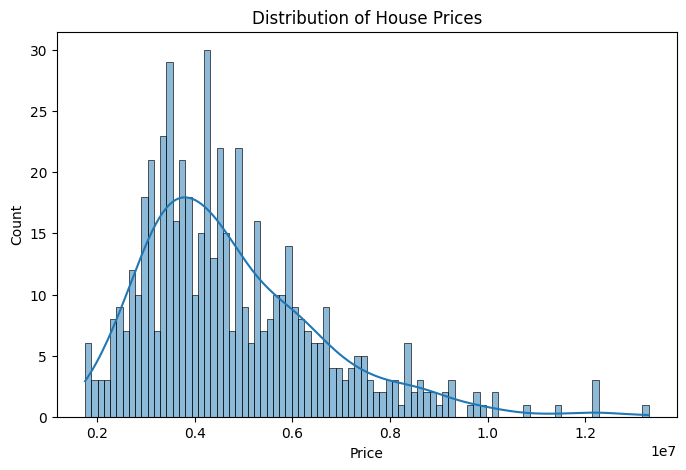

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df['price'],bins=90, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

## Feature Selection

The following variables are selected because they are expected to influence house prices.

- Area → Larger houses generally cost more.
- Bedrooms → More bedrooms increase property value.
- Bathrooms → Houses with more bathrooms are usually more expensive.
- Stories → Multi-storey houses often have higher prices.
- Main Road → Easy accessibility increases value.
- Guest Room → Additional rooms improve selling price.
- Basement → Adds usable living space.
- Air Conditioning → Improves comfort and increases price.
- Parking → More parking spaces increase value.
- Preferred Area → Houses in premium locations generally cost more.
- Furnishing Status → Fully furnished houses often have higher prices.

In [14]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_columns:
    df[col].fillna(df[col].median())


In [15]:
categorical_columns = df.select_dtypes(include=['object']).columns

for col in categorial_columns:
    df[col].fillna(df[col].mode()[0])

NameError: name 'categorial_columns' is not defined

In [ ]:
y=df["price"]

In [ ]:
X=df.drop("price",axis=1)

In [ ]:
print("X:", X.head())
print("y: \n", y.head())

X:    area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  7420         4          2        3      yes        no       no   
1  8960         4          4        4      yes        no       no   
2  9960         3          2        2      yes        no      yes   
3  7500         4          2        2      yes        no      yes   
4  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  
y: 
 0    13300000
1    12250000
2    12250000
3    12215000
4    11410000
Name: price, dtype: int64


In [ ]:
categorial_columns = df.select_dtypes(include=['object']).columns

numerical_columns = df.select_dtypes(exclude=['object']).columns

print("Catagorial Columns")
print(categorical_columns)

print("Numerical Columns")
print(numerical_columns)

Catagorial Columns
Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')
Numerical Columns
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object')


One Hot Encoding

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical_columns)
    ],
    remainder="passthrough"
)

Transform the Dataset

In [ ]:
X_encoded = preprocessor.fit_transform(X)
X_encoded

array([[1., 0., 0., ..., 2., 3., 2.],
       [1., 0., 0., ..., 4., 4., 3.],
       [1., 0., 1., ..., 2., 2., 2.],
       ...,
       [1., 0., 0., ..., 1., 1., 0.],
       [0., 0., 0., ..., 1., 1., 0.],
       [1., 0., 0., ..., 1., 2., 0.]], shape=(545, 13))

Display Encoded feature names

In [ ]:
encoded_feature_names = preprocessor.get_feature_names_out()
encoded_feature_names

array(['cat__mainroad_yes', 'cat__guestroom_yes', 'cat__basement_yes',
       'cat__hotwaterheating_yes', 'cat__airconditioning_yes',
       'cat__prefarea_yes', 'cat__furnishingstatus_semi-furnished',
       'cat__furnishingstatus_unfurnished', 'remainder__area',
       'remainder__bedrooms', 'remainder__bathrooms',
       'remainder__stories', 'remainder__parking'], dtype=object)

Convert Encoded Data to Dataframe

In [ ]:
X_encoded_df = pd.DataFrame(
    X_encoded,
    columns=preprocessor.get_feature_names_out()
)

X_encoded_df.head()

,cat__mainroad_yes,cat__guestroom_yes,cat__basement_yes,cat__hotwaterheating_yes,cat__airconditioning_yes,cat__prefarea_yes,cat__furnishingstatus_semi-furnished,cat__furnishingstatus_unfurnished,remainder__area,remainder__bedrooms,remainder__bathrooms,remainder__stories,remainder__parking
0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,7420.0,4.0,2.0,3.0,2.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,8960.0,4.0,4.0,4.0,3.0
2,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,9960.0,3.0,2.0,2.0,2.0
3,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,7500.0,4.0,2.0,2.0,3.0
4,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,7420.0,4.0,1.0,2.0,2.0


## Feature Engineering

The dataset contains several categorical variables such as:
- Main Road
- Guest Room
- Basement
- Air Conditioning
- Preferred Area
- Furnishing Status

Machine Learning algorithms cannot directly process text values. Therefore, One-Hot Encoding was applied to convert categorical variables into binary (0/1) columns.

The `drop='first'` option was used to avoid multicollinearity (Dummy Variable Trap), improving model stability and interpretability.

Correlation HeatMap

In [ ]:
correlation = df.corr(numeric_only=True)
correlation

,price,area,bedrooms,bathrooms,stories,parking
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.384394
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.352980
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,0.139270
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.177496
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.045547
parking,0.384394,0.352980,0.139270,0.177496,0.045547,1.000000


Plot the Correlation HeatMap

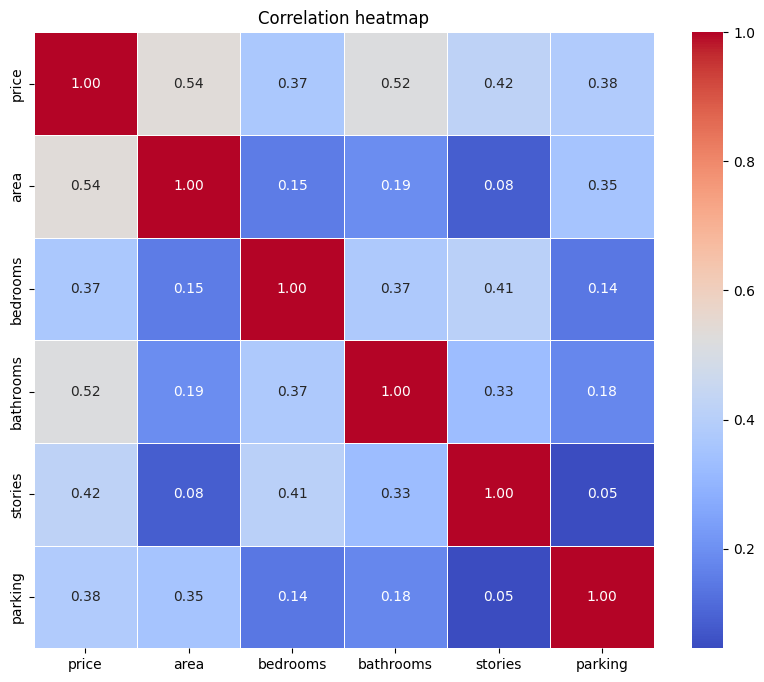

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation heatmap")
plt.show()

A heatmap where

    Red : Strong positive correlation

    Blue : Strong negative correlation

    White/Light colors : Weak or no correlation

Correlation with House Price

In [ ]:
correlation["price"].sort_values(ascending=False)

price        1.000000
area         0.535997
bathrooms    0.517545
stories      0.420712
parking      0.384394
bedrooms     0.366494
Name: price, dtype: float64

## Correlation Analysis

The correlation heatmap shows the strength of the relationship between numerical variables.



- **Area** has one of the strongest positive correlations with house price.
- **Bathrooms** and **stories** also show a positive relationship with price.
- **Parking** contributes positively to house prices.
- Features with correlation values close to **0** have little linear relationship with price.
- No extremely high correlation exists between most predictor variables, indicating limited multicollinearity.

Train-Test Split (80/20)

In [ ]:


X_train,X_test,y_train,y_test = train_test_split(
    X_encoded_df,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
#Check the Shape

print("Training Features :",X_train.shape)
print("Testing Features :",X_test.shape)

print("Training Target :",y_train.shape)
print("Testing Target :",y_test.shape)

Training Features : (436, 13)
Testing Features : (109, 13)
Training Target : (436,)
Testing Target : (109,)


## Train-Test Split

The dataset was divided into:

- **80% Training Data**: Used to train the Linear Regression model.
- **20% Testing Data**: Used to evaluate the model on unseen data.

The `random_state=42` parameter ensures that the split is reproducible.

Train the Linear Regression Model

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [ ]:
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

prediction_df = pd.DataFrame({
        "Actual Price " : y_test.values,
        "Predicted Price ":y_pred
    }
)
prediction_df.head(10)

,Actual Price,Predicted Price
0,4060000,5.164654e+06
1,6650000,7.224722e+06
2,3710000,3.109863e+06
3,6440000,4.612075e+06
4,2800000,3.294646e+06
5,4900000,3.532275e+06
6,5250000,5.611775e+06
7,4543000,6.368146e+06
8,2450000,2.722857e+06
9,3353000,2.629406e+06


Mean Squared Error (MSE)

In [ ]:
mse=mean_squared_error(y_test,y_pred)

print("Mean Squared Error : ", mse)

Mean Squared Error :  1754318687330.7024


Root Mean Squared Error

In [ ]:
rmse = np.sqrt(mse)
print("Root Mean Squared Error : ",rmse)

Root Mean Squared Error :  1324506.9600914533


R² Score

In [ ]:
r2=r2_score(y_test,y_pred)

print("R² Score : ",r2)

R² Score :  0.6529242642153108


In [ ]:
print("="*40)
print("Model Evaluation")
print("="*40)

print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

Model Evaluation
MSE  : 1754318687330.70
RMSE : 1324506.96
R²   : 0.6529


## Model Evaluation

The Linear Regression model was evaluated using three standard regression metrics:

### Mean Squared Error (MSE)
- Measures the average squared difference between actual and predicted house prices.
- Lower values indicate better performance.

### Root Mean Squared Error (RMSE)
- Square root of the MSE.
- Expressed in the same units as the target variable (price), making it easier to interpret.

### R² Score (Coefficient of Determination)
- Indicates how well the model explains the variation in house prices.
- A value close to **1** indicates a strong predictive model.
- A value close to **0** indicates poor predictive performance.

Scatter Plot

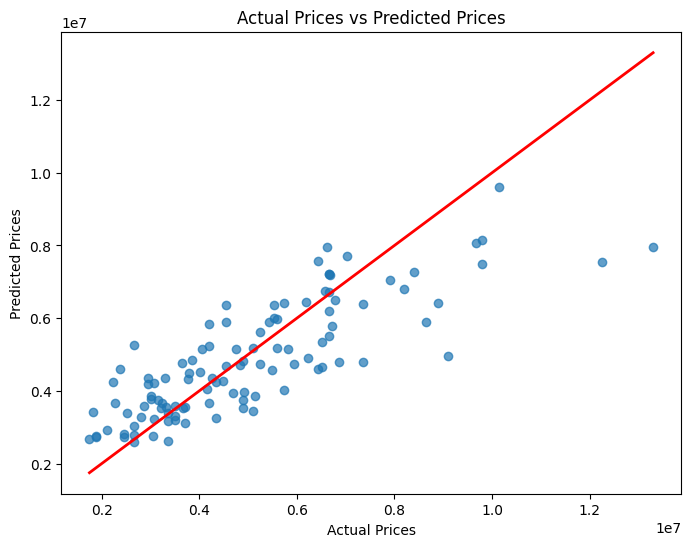

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.title("Actual Prices vs Predicted Prices")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.show()


Residual Plot

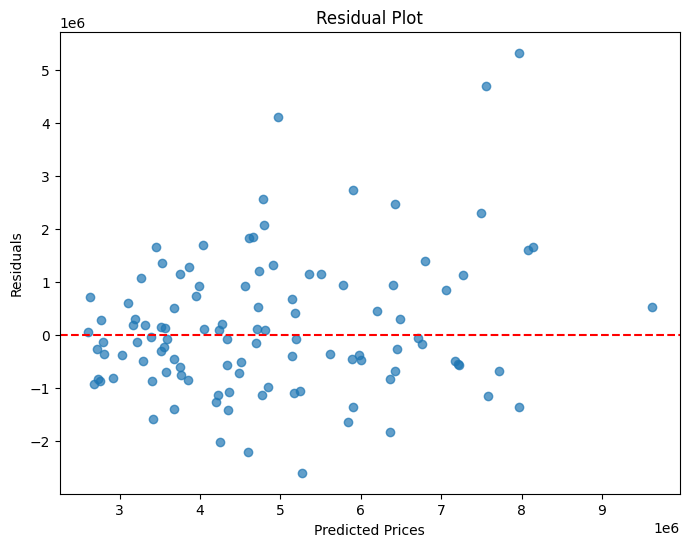

In [ ]:

residuals = y_test - y_pred
plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals, alpha=0.7)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.title("Residual Plot")
plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")

plt.show()

Coefficient Analysis

    The coefficients tell us how each feature influences the house price

In [ ]:
feature_names = preprocessor.get_feature_names_out()
coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,cat__mainroad_yes,3.679199e+05
1,cat__guestroom_yes,2.316100e+05
2,cat__basement_yes,3.902512e+05
3,cat__hotwaterheating_yes,6.846499e+05
4,cat__airconditioning_yes,7.914267e+05
5,cat__prefarea_yes,6.298906e+05
6,cat__furnishingstatus_semi-furnished,-1.268818e+05
7,cat__furnishingstatus_unfurnished,-4.136451e+05
8,remainder__area,2.359688e+02
9,remainder__bedrooms,7.677870e+04


In [ ]:
#Sort by Coefficients
coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

coefficients

,Feature,Coefficient
10,remainder__bathrooms,1.094445e+06
4,cat__airconditioning_yes,7.914267e+05
3,cat__hotwaterheating_yes,6.846499e+05
5,cat__prefarea_yes,6.298906e+05
11,remainder__stories,4.074766e+05
2,cat__basement_yes,3.902512e+05
0,cat__mainroad_yes,3.679199e+05
1,cat__guestroom_yes,2.316100e+05
12,remainder__parking,2.248419e+05
9,remainder__bedrooms,7.677870e+04


In [ ]:
# Top Positive Features
coefficients.head(10)

,Feature,Coefficient
10,remainder__bathrooms,1.094445e+06
4,cat__airconditioning_yes,7.914267e+05
3,cat__hotwaterheating_yes,6.846499e+05
5,cat__prefarea_yes,6.298906e+05
11,remainder__stories,4.074766e+05
2,cat__basement_yes,3.902512e+05
0,cat__mainroad_yes,3.679199e+05
1,cat__guestroom_yes,2.316100e+05
12,remainder__parking,2.248419e+05
9,remainder__bedrooms,7.677870e+04


In [ ]:
# Top Negative coefficients
coefficients.tail(2)

,Feature,Coefficient
6,cat__furnishingstatus_semi-furnished,-126881.817585
7,cat__furnishingstatus_unfurnished,-413645.062228


Visualize Feature Importance

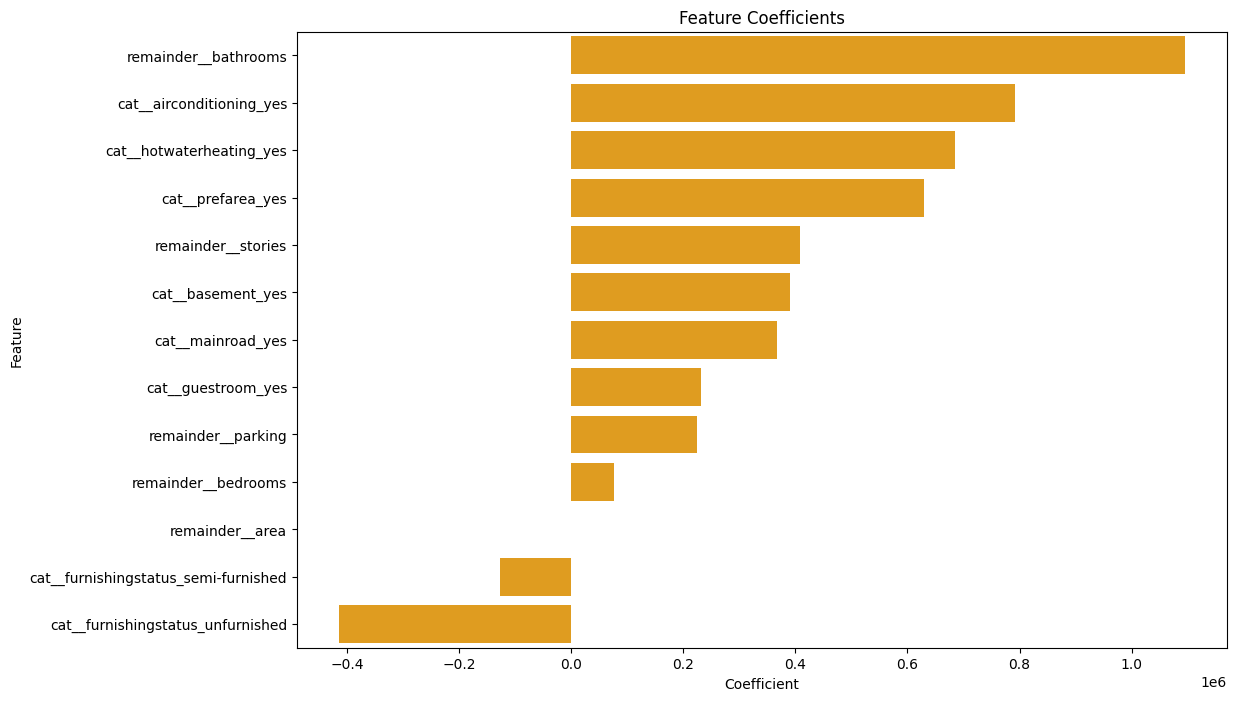

In [ ]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=coefficients,
    x="Coefficient",
    y="Feature",
    color="orange"
)

plt.title("Feature Coefficients")

plt.show()

## Coefficient Analysis

The coefficients indicate how each feature affects the predicted house price while keeping other variables constant.

### Positive Coefficients
Features with positive coefficients increase the predicted house price as their values increase.

Examples:
- Area
- Bathrooms
- Air Conditioning
- Parking
- Preferred Area

### Negative Coefficients
Features with negative coefficients decrease the predicted house price relative to the reference category.

Examples may include:
- Unfurnished status
- Certain encoded categorical variables

The magnitude of the coefficient reflects the strength of its influence on the prediction.

Compare With Ridge Regression

In [ ]:
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

Evaluate Ridge

In [ ]:
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression Results")
print("-"*30)
print(f"MSE  : {ridge_mse:.2f}")
print(f"RMSE : {ridge_rmse:.2f}")
print(f"R²   : {ridge_r2:.4f}")

Ridge Regression Results
------------------------------
MSE  : 1756474279575.28
RMSE : 1325320.44
R²   : 0.6525


Compare Linear Regression vs Ridge

In [ ]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "MSE": [mse, ridge_mse],
    "RMSE": [rmse, ridge_rmse],
    "R² Score": [r2, ridge_r2]
})

comparison

,Model,MSE,RMSE,R² Score
0,Linear Regression,1.754319e+12,1.324507e+06,0.652924
1,Ridge Regression,1.756474e+12,1.325320e+06,0.652498


Project Conclusion

# Conclusion

A Linear Regression model was successfully developed to predict house prices using property-related features such as area, number of bedrooms, bathrooms, parking, and furnishing status.

The project included:
- Data loading and exploration (EDA)
- Missing value checking
- Feature selection
- One-Hot Encoding for categorical variables
- Correlation analysis
- Train-test split (80/20)
- Model training using Linear Regression
- Performance evaluation using MSE, RMSE, and R² Score
- Visualization of Actual vs Predicted prices
- Residual analysis
- Coefficient analysis
- Comparison with Ridge Regression

The evaluation metrics indicate that the model captures a substantial portion of the variation in house prices. Features such as area, bathrooms, and parking generally have a positive influence on price, while some categorical variables may reduce the predicted value relative to the reference category.

The Ridge Regression model provides a useful comparison and may offer slightly better generalization by reducing the impact of very large coefficients.

In [ ]:
# Save the cleaned dataset
df.to_csv("House_Prediction.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
